In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [2]:
col = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
df = pd.read_csv('../data/magic04.data', names=col)
df['class'] = (df['class'] == 'g').astype(int)
df['class'].unique

<bound method Series.unique of 0        1
1        1
2        1
3        1
4        1
        ..
19015    0
19016    0
19017    0
19018    0
19019    0
Name: class, Length: 19020, dtype: int64>

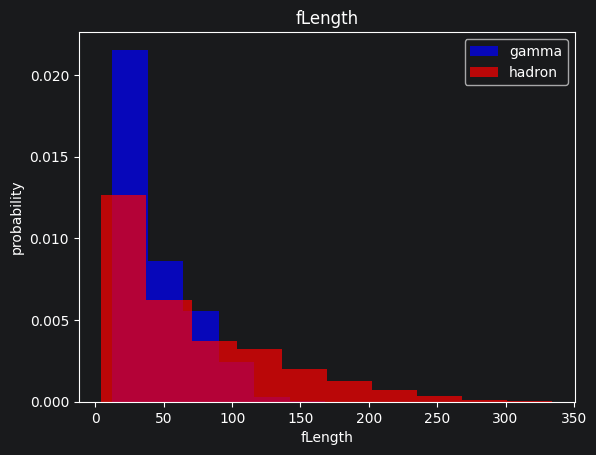

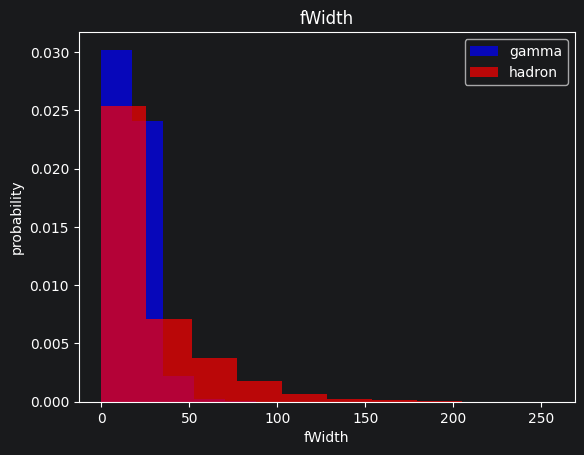

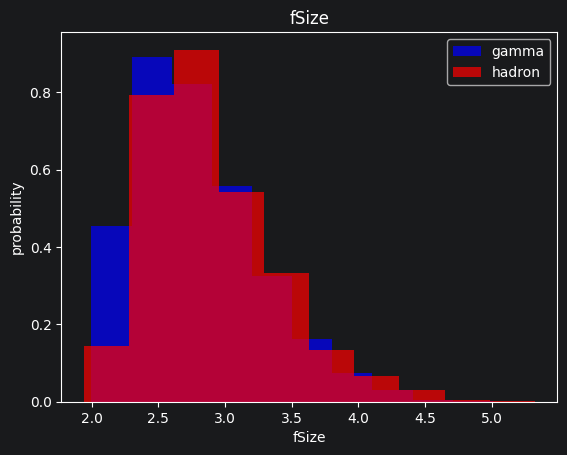

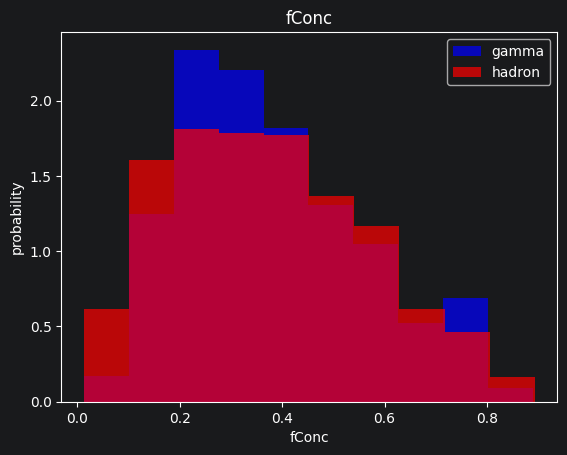

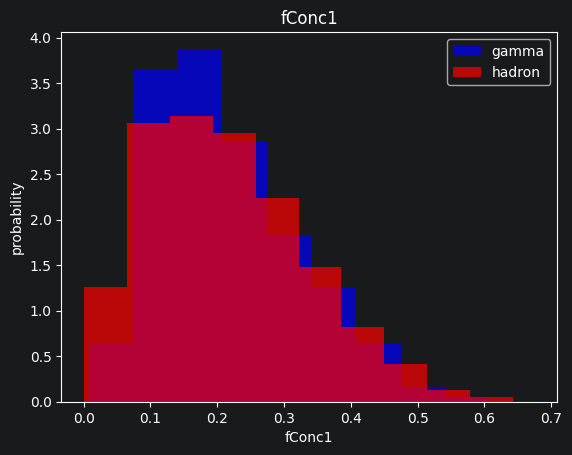

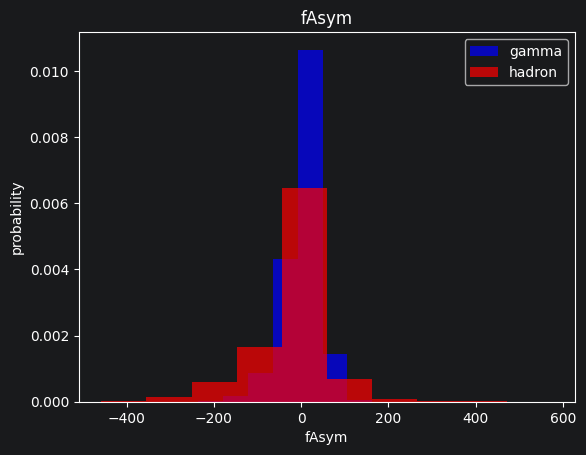

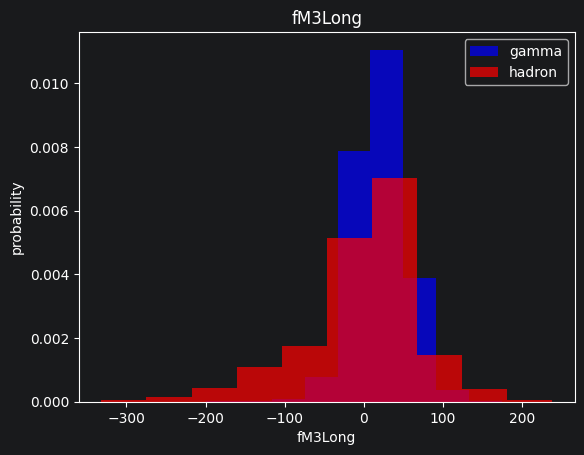

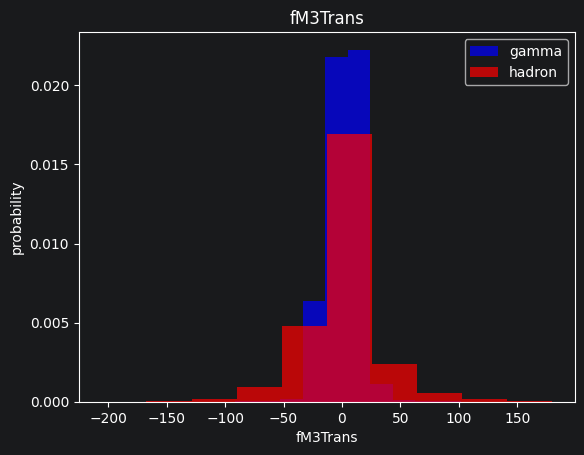

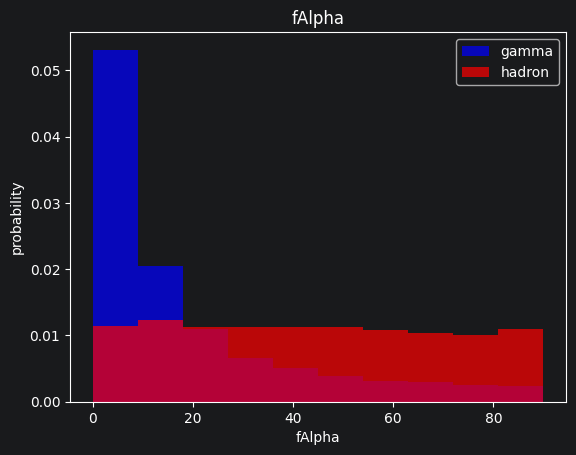

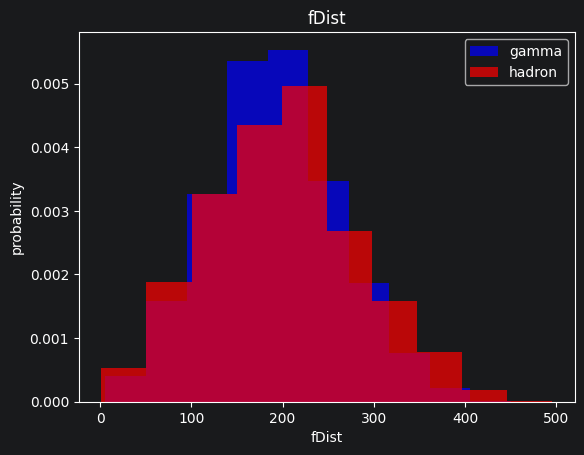

In [3]:
for label in col[:-1]: #plot probability that a entry is gamma or hadron given values from the other categories
    plt.hist(df[df['class']==1][label], color = 'blue', label = 'gamma', alpha = 0.7, density=True)# density = true normalizes each data point
    plt.hist(df[df['class']==0][label], color = 'red', label = 'hadron', alpha = 0.7, density=True)
    plt.title(label)
    plt.ylabel('probability')
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [4]:
shuffled_df = df.sample(frac=1, random_state=42)

train, valid, test = (
    shuffled_df.iloc[:int(0.6 * len(shuffled_df))],
    shuffled_df.iloc[int(0.6 * len(shuffled_df)):int(0.8 * len(shuffled_df))],
    shuffled_df.iloc[int(0.8 * len(shuffled_df)):]
)

In [5]:
def scale_dataset(dataframe, oversample=False):# we want to rescale our values because if some categories have larger numbers than others, some models can incorrectly assume they are more important
    X = dataframe[dataframe.columns[:-1]].values # creates a 2d array with the values of every column other than "class"
    y = dataframe[dataframe.columns[-1]].values # creates an array with the class values (0 and 1)

    scaler = StandardScaler()
    X = scaler.fit_transform(X) #scale the values of X so they become usable

    if oversample:
        ros = RandomOverSampler()
        X,y = ros.fit_resample(X, y) # there are fewer samples where class = 0, so oversample the amount of samples where class = 0.
                                     # That means randomly duplicate samples where class = 0
                                     # until the amount of samples where class = 0 is the same as the amount of samples where class =1

    data = np.hstack((X,np.reshape(y, (-1,1))))#giving -1 is telling np to infer what the length should be, same as saying len(y)
                                               #hstack puts X and y next to each other. So the nparray has the X entries, and then the y entries to the right
                                               #hstack requires both entries to be of the same dimensions, so we're basically making y a 2d array where the second dimension is 1

    return data, X, y

In [6]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)#don't oversample for the valid and test datasets. We want actual data for those.
test, X_test, y_test = scale_dataset(test, oversample=False)

# K-nearest neighbors

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [13]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
y_pred = knn_model.predict(X_test)

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      1331
           1       0.85      0.85      0.85      2473

    accuracy                           0.80      3804
   macro avg       0.78      0.78      0.78      3804
weighted avg       0.80      0.80      0.80      3804



# Naive Bayes

In [11]:
from sklearn.naive_bayes import GaussianNB

In [14]:
type(X_train)

numpy.ndarray

In [15]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [17]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.39      0.49      1331
           1       0.73      0.89      0.80      2473

    accuracy                           0.72      3804
   macro avg       0.69      0.64      0.65      3804
weighted avg       0.71      0.72      0.69      3804

